In [ ]:

# ============================================================
# ESTIMATIVA DA FREQUÊNCIA EFETIVA DO FORK CHOPPER
# Aplicação: bancada + dados reais do HATS
# Ambiente: Google Colab
# Gedeane G. S. Kenshima
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import io
import requests

from scipy import signal


# ------------------------------------------------------------
# FUNÇÃO 1 - FFT COM INTERPOLAÇÃO PARABÓLICA
# ------------------------------------------------------------

def estimar_fft_interpolada(
    y,
    fs,
    fmin=18.0,
    fmax=22.0
):
    """
    Estima a frequência dominante usando FFT,
    janela Hann e interpolação parabólica
    do logaritmo da magnitude espectral.
    """

    y = np.asarray(y)
    N = len(y)

    # Remove componente DC
    y0 = y - np.mean(y)

    # Janela Hann
    janela = signal.windows.hann(
        N,
        sym=False
    )

    # FFT unilateral
    Y = np.fft.rfft(
        y0 * janela
    )

    freq = np.fft.rfftfreq(
        N,
        d=1/fs
    )

    mag = np.abs(Y)

    # Região próxima à frequência do chopper
    mask = (
        (freq >= fmin)
        & (freq <= fmax)
    )

    indices = np.where(mask)[0]

    k = indices[
        np.argmax(mag[mask])
    ]

    f_bin = freq[k]

    # Interpolação parabólica
    # sobre o log da magnitude
    if 0 < k < len(mag)-1:

        a = np.log(
            mag[k-1] + 1e-30
        )

        b = np.log(
            mag[k] + 1e-30
        )

        c = np.log(
            mag[k+1] + 1e-30
        )

        denominador = (
            a - 2*b + c
        )

        if denominador != 0:

            delta = (
                0.5
                * (a-c)
                / denominador
            )

        else:
            delta = 0.0

    else:
        delta = 0.0

    df = freq[1] - freq[0]

    f_interp = (
        f_bin
        + delta * df
    )

    return f_interp, f_bin


# ------------------------------------------------------------
# FUNÇÃO 2 - ESTIMATIVA PELA FASE DE HILBERT
# ------------------------------------------------------------

def estimar_fase_hilbert(
    y,
    fs,
    f1=15.0,
    f2=25.0
):
    """
    Estima a frequência a partir da evolução
    temporal da fase do sinal analítico.

    O sinal é previamente filtrado em torno
    da frequência do chopper.
    """

    y = np.asarray(y)

    y0 = (
        y - np.mean(y)
    )

    # Filtro Butterworth passa-faixa
    sos = signal.butter(
        4,
        [f1, f2],
        btype="bandpass",
        fs=fs,
        output="sos"
    )

    yf = signal.sosfiltfilt(
        sos,
        y0
    )

    # Sinal analítico
    z = signal.hilbert(yf)

    fase = np.unwrap(
        np.angle(z)
    )

    amplitude = np.abs(z)

    t = (
        np.arange(len(y))
        / fs
    )

    # Descarta 1 s de cada extremidade
    # para reduzir efeitos de borda
    margem = int(fs)

    idx = np.arange(
        margem,
        len(y) - margem
    )

    # Remove regiões de amplitude muito baixa
    limite = np.percentile(
        amplitude[idx],
        30
    )

    idx = idx[
        amplitude[idx]
        >= limite
    ]

    # Ajuste linear:
    # fase(t) = omega*t + phi
    coef = np.polyfit(
        t[idx],
        fase[idx],
        1,
        w=np.sqrt(
            amplitude[idx]
        )
    )

    omega = coef[0]

    f_est = (
        omega
        / (2*np.pi)
    )

    return f_est

base_url_bancada = (
    "https://raw.githubusercontent.com/"
    "gedeanekenshima/ensaio17112025/main/"
)

resultados_bancada = []

for i in range(26):

    arquivo = f"T{i:04d}.CSV"
    url = base_url_bancada + arquivo

    print("Lendo:", arquivo)

    # --------------------------------------------------------
    # Baixa o arquivo como texto
    # --------------------------------------------------------
    resposta = requests.get(url)
    resposta.raise_for_status()

    texto = resposta.text
    linhas = texto.splitlines()

    # --------------------------------------------------------
    # Procura Sample Interval no cabeçalho
    # --------------------------------------------------------
    dt = None

    for linha in linhas[:20]:

        if linha.startswith("Sample Interval"):
            partes = linha.split(",")
            dt = float(partes[1])
            break

    if dt is None:
        raise ValueError(
            f"Sample Interval não encontrado em {arquivo}"
        )

    fs = 1.0 / dt

    # --------------------------------------------------------
    # Localiza a linha onde começam os dados
    # --------------------------------------------------------
    inicio_dados = None

    for j, linha in enumerate(linhas):

        if linha.startswith("TIME"):
            inicio_dados = j
            break

    if inicio_dados is None:
        raise ValueError(
            f"Cabeçalho TIME não encontrado em {arquivo}"
        )

    # --------------------------------------------------------
    # Lê somente a parte tabular
    # --------------------------------------------------------
    dados_csv = "\n".join(
        linhas[inicio_dados:]
    )

    dados = pd.read_csv(
        io.StringIO(dados_csv)
    )

    # Mostra informação apenas no primeiro arquivo
    if i == 0:
        print()
        print("Colunas encontradas:")
        print(dados.columns)
        print()

        print("Sample Interval:", dt, "s")
        print("Frequência de amostragem:", fs, "Hz")
        print("Número de amostras:", len(dados))
        print()

    y = dados["CH1"].to_numpy()

    # --------------------------------------------------------
    # FFT interpolada
    # --------------------------------------------------------
    f_fft, f_bin = estimar_fft_interpolada(
        y,
        fs
    )

    # --------------------------------------------------------
    # Hilbert
    # --------------------------------------------------------
    f_hilbert = estimar_fase_hilbert(
        y,
        fs
    )

    resultados_bancada.append({
        "arquivo": arquivo,
        "fs_Hz": fs,
        "N": len(y),
        "duracao_s": len(y) / fs,
        "bin_fft_Hz": f_bin,
        "freq_fft_Hz": f_fft,
        "freq_hilbert_Hz": f_hilbert
    })


df_bancada = pd.DataFrame(
    resultados_bancada
)

display(df_bancada)

Lendo: T0000.CSV

Colunas encontradas:
Index(['TIME', 'CH1', 'CH1 Peak Detect'], dtype='object')

Sample Interval: 0.00016 s
Frequência de amostragem: 6249.999999999999 Hz
Número de amostras: 125000

Lendo: T0001.CSV
Lendo: T0002.CSV
Lendo: T0003.CSV
Lendo: T0004.CSV
Lendo: T0005.CSV
Lendo: T0006.CSV
Lendo: T0007.CSV
Lendo: T0008.CSV
Lendo: T0009.CSV
Lendo: T0010.CSV
Lendo: T0011.CSV
Lendo: T0012.CSV
Lendo: T0013.CSV
Lendo: T0014.CSV
Lendo: T0015.CSV
Lendo: T0016.CSV
Lendo: T0017.CSV
Lendo: T0018.CSV
Lendo: T0019.CSV
Lendo: T0020.CSV
Lendo: T0021.CSV
Lendo: T0022.CSV
Lendo: T0023.CSV
Lendo: T0024.CSV
Lendo: T0025.CSV


,arquivo,fs_Hz,N,duracao_s,bin_fft_Hz,freq_fft_Hz,freq_hilbert_Hz
0,T0000.CSV,6250.0,125000,20.0,19.95,19.963620,19.962682
1,T0001.CSV,6250.0,125000,20.0,19.95,19.963464,19.958466
2,T0002.CSV,6250.0,125000,20.0,19.95,19.963362,19.962537
3,T0003.CSV,6250.0,125000,20.0,19.95,19.963172,19.962480
4,T0004.CSV,6250.0,125000,20.0,19.95,19.962971,19.961625
5,T0005.CSV,6250.0,125000,20.0,19.95,19.962847,19.962092
6,T0006.CSV,6250.0,125000,20.0,19.95,19.962543,19.960727
7,T0007.CSV,6250.0,125000,20.0,19.95,19.962340,19.961382
8,T0008.CSV,6250.0,125000,20.0,19.95,19.962267,19.961434
9,T0009.CSV,6250.0,125000,20.0,19.95,19.961787,19.960857


In [ ]:
# ------------------------------------------------------------
# 3. ESTATÍSTICA DOS 26 ARQUIVOS
# ------------------------------------------------------------

media_fft = df_bancada["freq_fft_Hz"].mean()
std_fft = df_bancada["freq_fft_Hz"].std(ddof=1)

media_hilbert = df_bancada["freq_hilbert_Hz"].mean()
std_hilbert = df_bancada["freq_hilbert_Hz"].std(ddof=1)

print("====================================")
print("RESULTADOS - BANCADA")
print("====================================")

print(
    f"FFT interpolada: "
    f"{media_fft:.6f} ± {std_fft:.6f} Hz"
)

print(
    f"Hilbert: "
    f"{media_hilbert:.6f} ± "
    f"{std_hilbert:.6f} Hz"
)

RESULTADOS - BANCADA
FFT interpolada: 19.961291 ± 0.001420 Hz
Hilbert: 19.957642 ± 0.004412 Hz


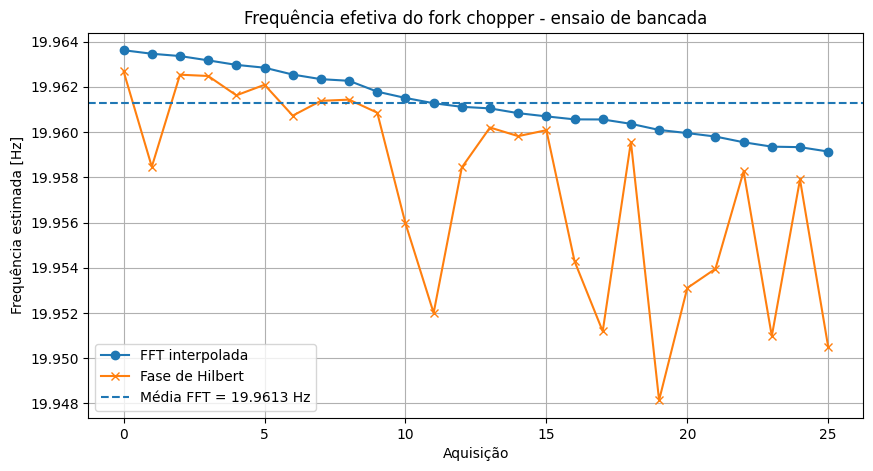

In [ ]:
import matplotlib.pyplot as plt

# ------------------------------------------------------------
# 4. GRÁFICO - BANCADA
# ------------------------------------------------------------

plt.figure(figsize=(10,5))

plt.plot(
    df_bancada.index,
    df_bancada["freq_fft_Hz"],
    marker="o",
    label="FFT interpolada"
)

plt.plot(
    df_bancada.index,
    df_bancada["freq_hilbert_Hz"],
    marker="x",
    label="Fase de Hilbert"
)

plt.axhline(
    media_fft,
    linestyle="--",
    label=f"Média FFT = {media_fft:.4f} Hz"
)

plt.xlabel("Aquisição")
plt.ylabel("Frequência estimada [Hz]")

plt.title(
    "Frequência efetiva do fork chopper "
    "- ensaio de bancada"
)

plt.grid()
plt.legend()

plt.show()

Trecho referente aos dados do HATS

In [ ]:

# ============================================================
# 5. DADOS REAIS DO HATS
# ============================================================

url_hats = (
    "https://raw.githubusercontent.com/"
    "gedeanekenshima/dados_reais_HATS/"
    "refs/heads/main/hats-2025-09-04.csv"
)

hats = pd.read_csv(url_hats)

display(hats.head())
print(hats.columns)

,husec,mVolts
0,477000005,412.551538
1,477000015,417.235624
2,477000025,415.528858
3,477000035,408.114408
4,477000045,395.435410


Index(['husec', 'mVolts'], dtype='object')


In [ ]:
y_hats = hats["mVolts"].values

fs_hats = 1000.0

N = len(y_hats)

duracao = N / fs_hats

print("Número de amostras:", N)
print("Duração:", duracao, "s")
print("Taxa de amostragem:", fs_hats, "Hz")

Número de amostras: 180000
Duração: 180.0 s
Taxa de amostragem: 1000.0 Hz


In [ ]:
# ------------------------------------------------------------
# 6. FFT - REGISTRO HATS COMPLETO
# ------------------------------------------------------------

f_fft_hats, f_bin_hats = estimar_fft_interpolada(
    y_hats,
    fs_hats,
    fmin=19,
    fmax=22
)

f_hilbert_hats = estimar_fase_hilbert(
    y_hats,
    fs_hats
)

print(
    f"Bin FFT de maior amplitude: "
    f"{f_bin_hats:.6f} Hz"
)

print(
    f"FFT interpolada: "
    f"{f_fft_hats:.6f} Hz"
)

print(
    f"Estimativa pela fase de Hilbert: "
    f"{f_hilbert_hats:.6f} Hz"
)

Bin FFT de maior amplitude: 20.333333 Hz
FFT interpolada: 20.333747 Hz
Estimativa pela fase de Hilbert: 20.333709 Hz


In [ ]:
# ------------------------------------------------------------
# 7. FREQUÊNCIA EM TRECHOS DE 10 s
# ------------------------------------------------------------

duracao_segmento = 10.0

N_segmento = int(
    duracao_segmento * fs_hats
)

resultados_segmentos = []

for inicio in range(
    0,
    len(y_hats) - N_segmento + 1,
    N_segmento
):

    fim = inicio + N_segmento

    segmento = y_hats[inicio:fim]

    f_seg, _ = estimar_fft_interpolada(
        segmento,
        fs_hats,
        fmin=19,
        fmax=22
    )

    resultados_segmentos.append({
        "inicio_s": inicio/fs_hats,
        "fim_s": fim/fs_hats,
        "freq_Hz": f_seg
    })


df_segmentos = pd.DataFrame(
    resultados_segmentos
)

display(df_segmentos)

,inicio_s,fim_s,freq_Hz
0,0.0,10.0,20.335509
1,10.0,20.0,20.335465
2,20.0,30.0,20.335567
3,30.0,40.0,20.335938
4,40.0,50.0,20.335812
5,50.0,60.0,20.335121
6,60.0,70.0,20.335655
7,70.0,80.0,20.335192
8,80.0,90.0,20.335088
9,90.0,100.0,20.335405


In [ ]:
# ------------------------------------------------------------
# 5. ESTATÍSTICA DOS SEGMENTOS DO HATS
# ------------------------------------------------------------

df_segmentos = pd.DataFrame(resultados_segmentos)

media_hats = df_segmentos["freq_Hz"].mean()
std_hats = df_segmentos["freq_Hz"].std(ddof=1)

freq_min = df_segmentos["freq_Hz"].min()
freq_max = df_segmentos["freq_Hz"].max()

print("====================================")
print("RESULTADOS - HATS")
print("====================================")

print(
    f"Frequência média nos segmentos: "
    f"{media_hats:.6f} ± {std_hats:.6f} Hz"
)

print(
    f"Frequência mínima: "
    f"{freq_min:.6f} Hz"
)

print(
    f"Frequência máxima: "
    f"{freq_max:.6f} Hz"
)

RESULTADOS - HATS
Frequência média nos segmentos: 20.335219 ± 0.000606 Hz
Frequência mínima: 20.333528 Hz
Frequência máxima: 20.335998 Hz


In [ ]:
# Recria o DataFrame usando os resultados da célula anterior
df_segmentos = pd.DataFrame(resultados_segmentos)

display(df_segmentos)

media_hats = df_segmentos["freq_Hz"].mean()
std_hats = df_segmentos["freq_Hz"].std(ddof=1)

freq_min = df_segmentos["freq_Hz"].min()
freq_max = df_segmentos["freq_Hz"].max()

print("====================================")
print("RESULTADOS - HATS")
print("====================================")

print(
    f"Frequência média nos segmentos: "
    f"{media_hats:.6f} ± {std_hats:.6f} Hz"
)

print(f"Frequência mínima: {freq_min:.6f} Hz")
print(f"Frequência máxima: {freq_max:.6f} Hz")

,inicio_s,fim_s,freq_Hz
0,0.0,10.0,20.335509
1,10.0,20.0,20.335465
2,20.0,30.0,20.335567
3,30.0,40.0,20.335938
4,40.0,50.0,20.335812
5,50.0,60.0,20.335121
6,60.0,70.0,20.335655
7,70.0,80.0,20.335192
8,80.0,90.0,20.335088
9,90.0,100.0,20.335405


RESULTADOS - HATS
Frequência média nos segmentos: 20.335219 ± 0.000606 Hz
Frequência mínima: 20.333528 Hz
Frequência máxima: 20.335998 Hz
